In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:

df = pd.read_csv("clean_normal_cells.csv")

print(df.columns.tolist())

['Date', 'eNodeB Name', 'Cell FDD TDD Indication', 'Cell Name', 'LocalCell Id', 'Cluster', 'Downlink EARFCN', 'Integrity', '(HU) Cell Unavail Time (s)', '(HU) DL Traffic Volume (GBytes)', '(HU) UL Traffic Volume (GBytes)', '(HU) Average UE Number', 'L.Traffic.ActiveUser.Avg', 'L.Traffic.ActiveUser.Dl.Avg', 'L.Traffic.ActiveUser.UL.Avg', 'L.Traffic.User.BorderUE.Avg', '(HU) Cell DL Average Throughput (Mbps)', '(HU) Cell UL Average Throughput (Mbps)', '(HU) User DL Average Throughput (Mbps)', '(HU) User UL Average Throughput (Mbps)', '(HU)CEU Cell Downlink Average Throughput', '(HU)CEU Cell Uplink Average Throughput', '(HU)CEU User Downlink Average Througput', '(HU)CEU User Uplink Average Throughput', 'L.CA.UE.Avg', 'L.RRC.ConnReq.Att', 'RRC Setup Failure Time', '(TE) RRC Setup SR%', 'RRC MO Signaling Failure Times', 'RRC Setup(Service) Attempt  Times', 'RRC Setup Success (Service) Rate(%)', 'RRC Connection Drop Rate%', 'L.E-RAB.AttEst', 'ERAB Setup Failure Times', 'ERAB Setup Success Ra

In [3]:
target = "(HU) Cell DL Average Throughput (Mbps)"

In [4]:
df["Date"] = pd.to_datetime(df["Date"])

cell_name = df["Cell Name"].iloc[3]

cell_df = (
    df[df["Cell Name"] == cell_name]
    .sort_values("Date")
)

series = cell_df[["Date",
                  "(HU) Cell DL Average Throughput (Mbps)"]]

series = series.rename(
    columns={"(HU) Cell DL Average Throughput (Mbps)":"y"}
)

print(series.head())

           Date        y
3    2026-04-19  11.9119
288  2026-04-20  11.5562
567  2026-04-21  11.5189
835  2026-04-22  11.6527
1105 2026-04-23  11.3282


In [5]:
target = "(HU) Cell DL Average Throughput (Mbps)"

features = [
    "(HU) Average UE Number",
    "(HU) DL Traffic Volume (GBytes)",
    "L.Traffic.ActiveUser.Avg"
]

In [6]:
X = cell_df[features]
y = cell_df[target]

In [7]:
import pandas as pd

# Load data
df = pd.read_csv("clean_normal_cells.csv")

# Convert date column
df["Date"] = pd.to_datetime(df["Date"])

# Rename target column
df = df.rename(columns={
    "(HU) Cell DL Average Throughput (Mbps)": "DL_Throughput"
})

# Remove missing values
df = df.dropna(subset=["DL_Throughput"])

# Select one cell
cell_name = df["Cell Name"].iloc[3]

cell_df = (
    df[df["Cell Name"] == cell_name]
    .groupby("Date")["DL_Throughput"]
    .mean()
    .sort_index()
)

# Daily frequency
cell_df = cell_df.asfreq("D", method="ffill")

print(cell_df.head())

Date
2026-04-19    11.9119
2026-04-20    11.5562
2026-04-21    11.5189
2026-04-22    11.6527
2026-04-23    11.3282
Freq: D, Name: DL_Throughput, dtype: float64


In [8]:
FORECAST_HORIZON = 7

train = cell_df[:-FORECAST_HORIZON]
test = cell_df[-FORECAST_HORIZON:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 23
Test size: 7


In [9]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

In [10]:
arima_model = ARIMA(train, order=(2,1,2))
arima_fit = arima_model.fit()

c:\Users\M2h\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\M2h\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [11]:
forecast_arima = arima_fit.forecast(steps=7)

mae_arima = mean_absolute_error(test, forecast_arima)

print("ARIMA MAE:", round(mae_arima,3))

ARIMA MAE: 0.495


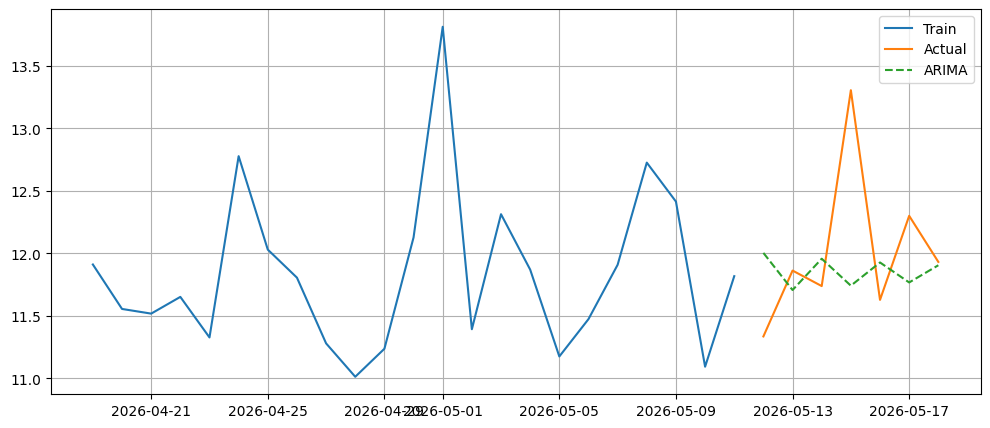

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast_arima, "--", label="ARIMA")

plt.legend()
plt.grid()
plt.show()

In [13]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [14]:
sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(2,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

c:\Users\M2h\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\M2h\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:1235: RuntimeWarning: invalid value encountered in divide
  np.inner(score_obs, score_obs) /


In [15]:
forecast_sarima = sarima_fit.forecast(steps=7)

mae_sarima = mean_absolute_error(test, forecast_sarima)

print("SARIMA MAE:", round(mae_sarima,3))

SARIMA MAE: 0.55


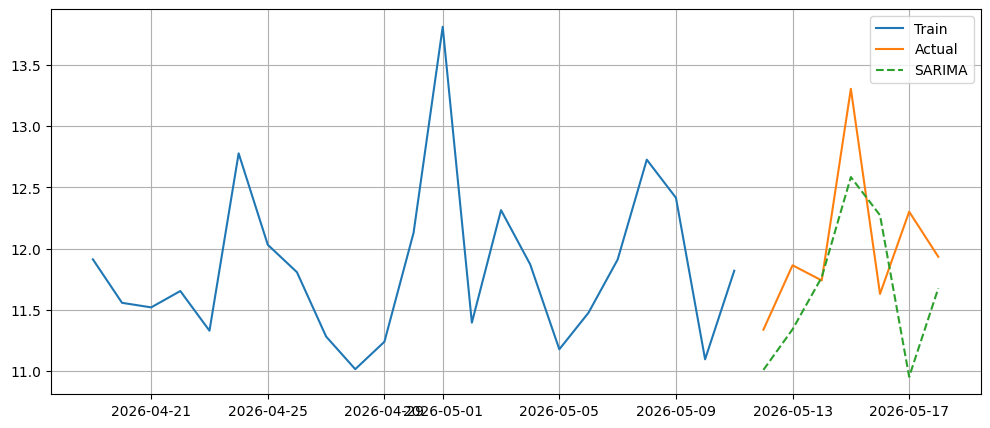

In [16]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast_sarima, "--", label="SARIMA")

plt.legend()
plt.grid()
plt.show()

In [17]:
pred = sarima_fit.get_forecast(steps=7)

forecast = pred.predicted_mean
conf_int = pred.conf_int()

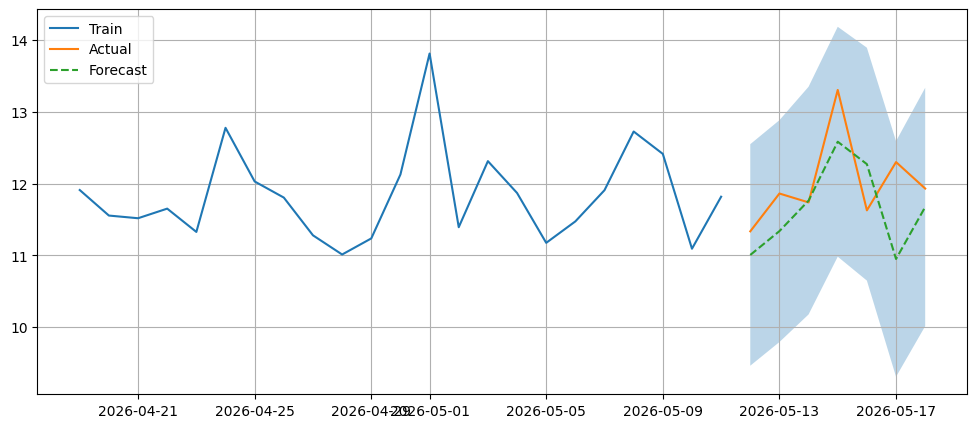

In [18]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(forecast.index, forecast, "--", label="Forecast")

plt.fill_between(
    forecast.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    alpha=0.3
)

plt.legend()
plt.grid()
plt.show()

In [19]:
%pip install pmdarima

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

In [21]:
FORECAST_HORIZON = 7

train = cell_df[:-FORECAST_HORIZON]
test = cell_df[-FORECAST_HORIZON:]

In [22]:
model = auto_arima(
    train,
    seasonal=True,
    m=7,                  # weekly seasonality
    start_p=0,
    start_q=0,
    max_p=5,
    max_q=5,
    max_P=2,
    max_Q=2,
    d=None,
    D=None,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    information_criterion='aic'
)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(1,1,1)[7] intercept   : AIC=31.371, Time=0.35 sec
 ARIMA(0,0,0)(0,1,0)[7] intercept   : AIC=36.365, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[7] intercept   : AIC=28.944, Time=0.20 sec
 ARIMA(0,0,1)(0,1,1)[7] intercept   : AIC=inf, Time=0.34 sec
 ARIMA(0,0,0)(0,1,0)[7]             : AIC=34.369, Time=0.02 sec
 ARIMA(1,0,0)(0,1,0)[7] intercept   : AIC=37.379, Time=0.03 sec
 ARIMA(1,0,0)(2,1,0)[7] intercept   : AIC=30.352, Time=0.27 sec
 ARIMA(1,0,0)(1,1,1)[7] intercept   : AIC=30.351, Time=0.60 sec
 ARIMA(1,0,0)(0,1,1)[7] intercept   : AIC=inf, Time=0.37 sec
 ARIMA(1,0,0)(2,1,1)[7] intercept   : AIC=32.351, Time=0.77 sec
 ARIMA(0,0,0)(1,1,0)[7] intercept   : AIC=29.626, Time=0.27 sec
 ARIMA(2,0,0)(1,1,0)[7] intercept   : AIC=30.488, Time=0.27 sec
 ARIMA(1,0,1)(1,1,0)[7] intercept   : AIC=inf, Time=1.18 sec
 ARIMA(0,0,1)(1,1,0)[7] intercept   : AIC=27.997, Time=0.28 sec
 ARIMA(0,0,1)(0,1,0)[7] intercept   : AIC=37.333, Time=0.11 sec
 ARIMA

In [23]:
forecast = model.predict(n_periods=7)

In [24]:
mae = mean_absolute_error(test, forecast)

print("MAE =", round(mae,3))

MAE = 0.282


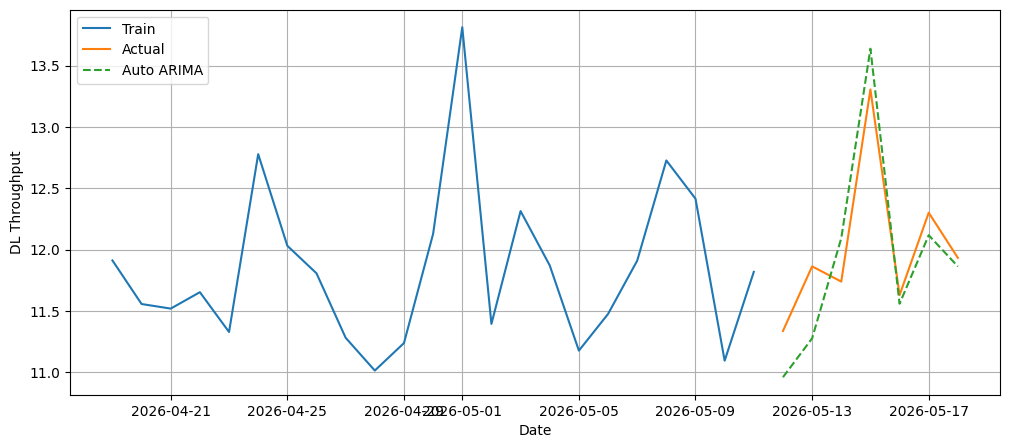

In [25]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast, '--', label="Auto ARIMA")

plt.xlabel("Date")
plt.ylabel("DL Throughput")
plt.legend()
plt.grid()
plt.show()

In [26]:
model = auto_arima(
    train,
    seasonal=True,
    m=7,
    max_p=3,
    max_q=3,
    max_P=2,
    max_Q=2,
    stepwise=True,
    trace=True
)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[7] intercept   : AIC=inf, Time=1.18 sec
 ARIMA(0,0,0)(0,1,0)[7] intercept   : AIC=36.365, Time=0.03 sec
 ARIMA(1,0,0)(1,1,0)[7] intercept   : AIC=28.944, Time=0.15 sec
 ARIMA(0,0,1)(0,1,1)[7] intercept   : AIC=inf, Time=0.29 sec
 ARIMA(0,0,0)(0,1,0)[7]             : AIC=34.369, Time=0.02 sec
 ARIMA(1,0,0)(0,1,0)[7] intercept   : AIC=37.379, Time=0.03 sec
 ARIMA(1,0,0)(2,1,0)[7] intercept   : AIC=30.352, Time=0.25 sec
 ARIMA(1,0,0)(1,1,1)[7] intercept   : AIC=30.351, Time=0.44 sec
 ARIMA(1,0,0)(0,1,1)[7] intercept   : AIC=inf, Time=0.31 sec
 ARIMA(1,0,0)(2,1,1)[7] intercept   : AIC=32.351, Time=0.36 sec
 ARIMA(0,0,0)(1,1,0)[7] intercept   : AIC=29.626, Time=0.13 sec
 ARIMA(2,0,0)(1,1,0)[7] intercept   : AIC=30.488, Time=0.21 sec
 ARIMA(1,0,1)(1,1,0)[7] intercept   : AIC=inf, Time=0.67 sec
 ARIMA(0,0,1)(1,1,0)[7] intercept   : AIC=27.997, Time=0.19 sec
 ARIMA(0,0,1)(0,1,0)[7] intercept   : AIC=37.333, Time=0.07 sec
 ARIMA(0,

In [27]:
forecast, conf_int = model.predict(
    n_periods=7,
    return_conf_int=True
)

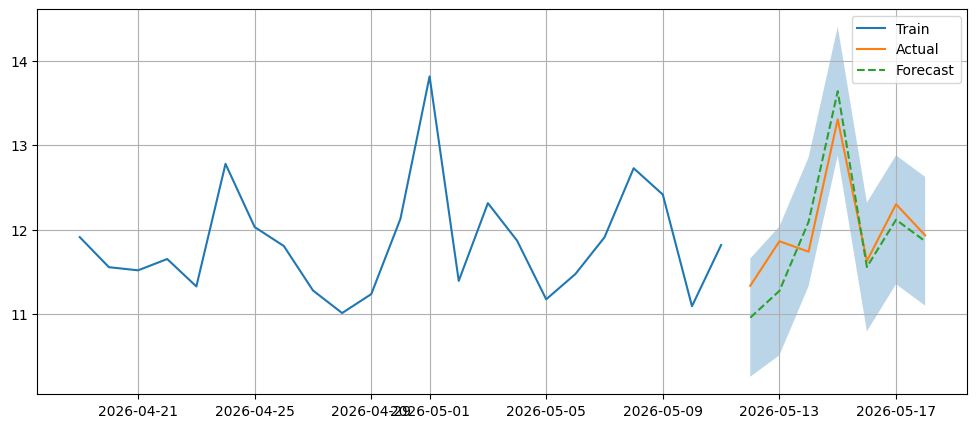

In [28]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, '--', label='Forecast')

plt.fill_between(
    test.index,
    conf_int[:,0],
    conf_int[:,1],
    alpha=0.3
)

plt.legend()
plt.grid()
plt.show()

In [29]:
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error
import numpy as np

series = cell_df.values

initial_train = 21
horizon = 2

maes = []

for end_train in range(initial_train, len(series)-horizon+1, horizon):

    train = series[:end_train]
    test = series[end_train:end_train+horizon]

    model = auto_arima(
        train,
        seasonal=True,
        m=7,
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore'
    )

    forecast = model.predict(n_periods=len(test))

    mae = mean_absolute_error(test, forecast)
    maes.append(mae)

print("Fold MAEs:", maes)
print("Average MAE:", np.mean(maes))

Fold MAEs: [0.6184734789193183, 0.4821937088641963, 0.27572014855264104, 0.1682020551434702]
Average MAE: 0.38614734786990645


In [ ]:
maes = []

for i in range(21, len(series)):

    train = series[:i]
    test = series[i:i+1]

    model = auto_arima(
        train,
        seasonal=True,
        m=7,
        stepwise=True,
        suppress_warnings=True
    )

    forecast = model.predict(1)

    maes.append(mean_absolute_error(test, forecast))

print("Average MAE =", np.mean(maes))

Average MAE = 0.3909340653413634
